# Caregiver Cluster Simple Metrics

This notebook gives a simple, local, decision-oriented summary of the caregiver acceptability project. It uses the project's cached REDCap exports, selected cohort file, configuration, and committed output tables to answer four practical questions:

1. What files and cohorts are available locally?
2. How many selected records are usable for clustering?
3. How balanced and how separated is the two-cluster solution?
4. How different is the held-out screening outcome across clusters?

The notebook deliberately avoids advanced fraud modeling and latent-profile extensions. The goal is a clean, reproducible metric view that is easy to inspect and easy to rerun.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA

from caregiver_analysis_pipeline import (
    CLUSTER_ORDER,
    _screen_summary,
    _verify_sha_sidecar,
    build_cluster_domains,
    fit_named_kmeans,
    load_config,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / "data_cache"
OUTPUT_DIR = PROJECT_DIR / "Caregiver Outputs"

if not (PROJECT_DIR / "config.yaml").exists():
    raise FileNotFoundError("Run this notebook from the caregiver-cluster-analysis project folder.")

config = load_config(PROJECT_DIR)
palette = {
    "Higher acceptability": config["figures"]["higher_acceptability"],
    "Conditional acceptability": config["figures"]["conditional_acceptability"],
}
accent = config["figures"]["ink"]

def load_latest_cache(project_id: int, content: str = "record") -> tuple[pd.DataFrame, Path]:
    matches = sorted(CACHE_DIR.glob(f"{project_id}_{content}_*.parquet"))
    if not matches:
        raise FileNotFoundError(f"No cached {content} file found for project {project_id}.")
    path = matches[-1]
    _verify_sha_sidecar(path)
    return pd.read_parquet(path), path

def load_selected_ids() -> pd.Series:
    selected_path = PROJECT_DIR / "cleaned_autism_study_data.csv"
    selected_column = pd.read_csv(selected_path, nrows=0).columns[0]
    return (
        pd.read_csv(selected_path, usecols=[selected_column])[selected_column]
        .pipe(pd.to_numeric, errors="coerce")
        .dropna()
        .astype(int)
        .astype(str)
    )

## 1. Local Project Inputs

The notebook uses the same local assets that anchor the rest of the project: the cached 4797 and 4581 REDCap pulls in `data_cache`, the selected cohort list in `cleaned_autism_study_data.csv`, `config.yaml` for clustering settings, and the committed CSV outputs in `Caregiver Outputs/` for validation.

The primary clustering analysis is run on the selected 4797 cohort because that is the stable local analysis path already represented across the project files.

In [2]:
clean_record, clean_path = load_latest_cache(4797)
dirty_record, dirty_path = load_latest_cache(4581)
selected_ids = load_selected_ids()

analysis_frame = clean_record.loc[clean_record["record_id"].astype(str).isin(selected_ids)].copy()
analysis_frame["record_id"] = analysis_frame["record_id"].astype(str)
analysis_frame["uid"] = "4797_" + analysis_frame["record_id"]
analysis_frame = analysis_frame.set_index("uid", drop=False)

project_assets = pd.DataFrame(
    [
        {"role": "Project configuration", "path": "config.yaml"},
        {"role": "Selected cohort file", "path": "cleaned_autism_study_data.csv"},
        {"role": "Coded CSV reference", "path": "InfantAutismScreenin-FullDataset_DATA_2026-01-20_0940.csv"},
        {"role": "Labeled CSV reference", "path": "InfantAutismScreenin-FullDataset_DATA_LABELS_2026-01-20_0940.csv"},
        {"role": "Cached 4797 record snapshot", "path": f"data_cache/{clean_path.name}"},
        {"role": "Cached 4581 record snapshot", "path": f"data_cache/{dirty_path.name}"},
        {"role": "Cluster diagnostics export", "path": "Caregiver Outputs/table_3_cluster_diagnostics.csv"},
        {"role": "Screening outcome export", "path": "Caregiver Outputs/table_5_screening_outcome.csv"},
    ]
)

cohort_inventory = pd.DataFrame(
    [
        {"stage": "4797 cached records", "n": len(clean_record), "note": "Verified-clean project snapshot"},
        {"stage": "4581 cached records", "n": len(dirty_record), "note": "Legacy project snapshot"},
        {"stage": "Selected analytic records", "n": len(analysis_frame), "note": "Rows matched from cleaned_autism_study_data.csv"},
    ]
)

display(project_assets)
display(cohort_inventory)

,role,path
0,Project configuration,config.yaml
1,Selected cohort file,cleaned_autism_study_data.csv
2,Coded CSV reference,InfantAutismScreenin-FullDataset_DATA_2026-01-...
3,Labeled CSV reference,InfantAutismScreenin-FullDataset_DATA_LABELS_2...
4,Cached 4797 record snapshot,data_cache/4797_record_2026-07-30.parquet
5,Cached 4581 record snapshot,data_cache/4581_record_2026-07-30.parquet
6,Cluster diagnostics export,Caregiver Outputs/table_3_cluster_diagnostics.csv
7,Screening outcome export,Caregiver Outputs/table_5_screening_outcome.csv


,stage,n,note
0,4797 cached records,177,Verified-clean project snapshot
1,4581 cached records,1779,Legacy project snapshot
2,Selected analytic records,135,Rows matched from cleaned_autism_study_data.csv


## 2. Metric Definitions

This notebook keeps the metric set intentionally small. The same project functions are reused for domain construction and k-means fitting, but the reported quantities are the ones that are easiest to interpret.

### Domain scaling
For each survey item that belongs in a TFA domain, the existing pipeline rescales responses to 0 to 100:

$$
	ext{score}_{0-100} = 
rac{x - in(x)}{ax(x) - in(x)} 	imes 100
$$

Reverse-coded items are flipped after scaling so that higher values always mean more of the domain being named.

### Clusterable rule
A selected caregiver enters clustering only if at least 8 of the 10 domain scores are observed:

$$
	ext{clusterable} = athbb{1}(	ext{non-missing domains} e 8)
$$

### Cluster separation
The main fit-quality metric is the silhouette score:

$$
s(i) = 
rac{b(i) - a(i)}{ax(a(i), b(i))}
$$

where $a(i)$ is the mean distance to the respondent's own cluster and $b(i)$ is the mean distance to the nearest other cluster.

### Held-out decision metric
The most decision-useful held-out outcome is the Definitely yes screening rate gap:

$$
elta = p_{	ext{Higher acceptability}} - p_{	ext{Conditional acceptability}}
$$

This is easy to explain because screening is not part of the clustering inputs.

In [3]:
fit = fit_named_kmeans(analysis_frame, config)
domains = build_cluster_domains(analysis_frame)
domain_observed_n = domains.notna().sum(axis=1)

screen_table, screen_gap, gap_low, gap_high = _screen_summary(analysis_frame, fit)
cluster_sizes = fit.named_labels.value_counts().reindex(CLUSTER_ORDER)
profile_table = (
    fit.profile_means.T
    .assign(gap=lambda df: df["Higher acceptability"] - df["Conditional acceptability"])
    .sort_values("gap", ascending=False)
)

expected_diag = pd.read_csv(OUTPUT_DIR / "table_3_cluster_diagnostics.csv")
expected_screen = pd.read_csv(OUTPUT_DIR / "table_5_screening_outcome.csv")

validation = pd.DataFrame(
    [
        {"metric": "selected rows", "notebook": len(analysis_frame), "project_export": 135},
        {"metric": "clusterable rows", "notebook": int(fit.eligible.sum()), "project_export": 131},
        {"metric": "higher cluster n", "notebook": int(cluster_sizes["Higher acceptability"]), "project_export": 84},
        {"metric": "conditional cluster n", "notebook": int(cluster_sizes["Conditional acceptability"]), "project_export": 47},
        {
            "metric": "silhouette",
            "notebook": float(fit.silhouette),
            "project_export": float(expected_diag.loc[expected_diag["k"].eq(2), "silhouette"].iloc[0]),
        },
        {
            "metric": "definitely yes gap (pp)",
            "notebook": float(screen_gap),
            "project_export": float(
                expected_screen.loc[expected_screen["cluster"].eq("Higher acceptability"), "definitely_yes_pct"].iloc[0]
                - expected_screen.loc[expected_screen["cluster"].eq("Conditional acceptability"), "definitely_yes_pct"].iloc[0]
            ),
        },
    ]
)
validation["difference"] = validation["notebook"] - validation["project_export"]

metric_summary = pd.DataFrame(
    [
        {"metric": "Clusterable rule", "value": f">= {config['analysis']['minimum_cluster_domains']} of 10 domains observed"},
        {"metric": "Selected analytic rows", "value": len(analysis_frame)},
        {"metric": "Clusterable rows", "value": int(fit.eligible.sum())},
        {"metric": "Clusterable share", "value": f"{fit.eligible.mean() * 100:.1f}%"},
        {"metric": "Higher acceptability n", "value": int(cluster_sizes['Higher acceptability'])},
        {"metric": "Conditional acceptability n", "value": int(cluster_sizes['Conditional acceptability'])},
        {"metric": "Silhouette (k=2)", "value": f"{fit.silhouette:.3f}"},
        {"metric": "Held-out Definitely yes gap", "value": f"{screen_gap:.1f} percentage points"},
        {"metric": "Gap 95% CI", "value": f"{gap_low:.1f} to {gap_high:.1f} percentage points"},
    ]
)

display(metric_summary)
display(validation.round(6))

,metric,value
0,Clusterable rule,>= 8 of 10 domains observed
1,Selected analytic rows,135
2,Clusterable rows,131
3,Clusterable share,97.0%
4,Higher acceptability n,84
5,Conditional acceptability n,47
6,Silhouette (k=2),0.180
7,Held-out Definitely yes gap,42.3 percentage points
8,Gap 95% CI,17.5 to 62.0 percentage points


,metric,notebook,project_export,difference
0,selected rows,135.000000,135.000000,0.0
1,clusterable rows,131.000000,131.000000,0.0
2,higher cluster n,84.000000,84.000000,0.0
3,conditional cluster n,47.000000,47.000000,0.0
4,silhouette,0.180263,0.180263,0.0
5,definitely yes gap (pp),42.340426,42.340426,0.0


## 3. Data Readiness

Before looking at cluster differences, the first question is whether enough of the selected cohort has usable TFA-domain data. The two most practical checks are the cohort flow and the distribution of observed domain counts.

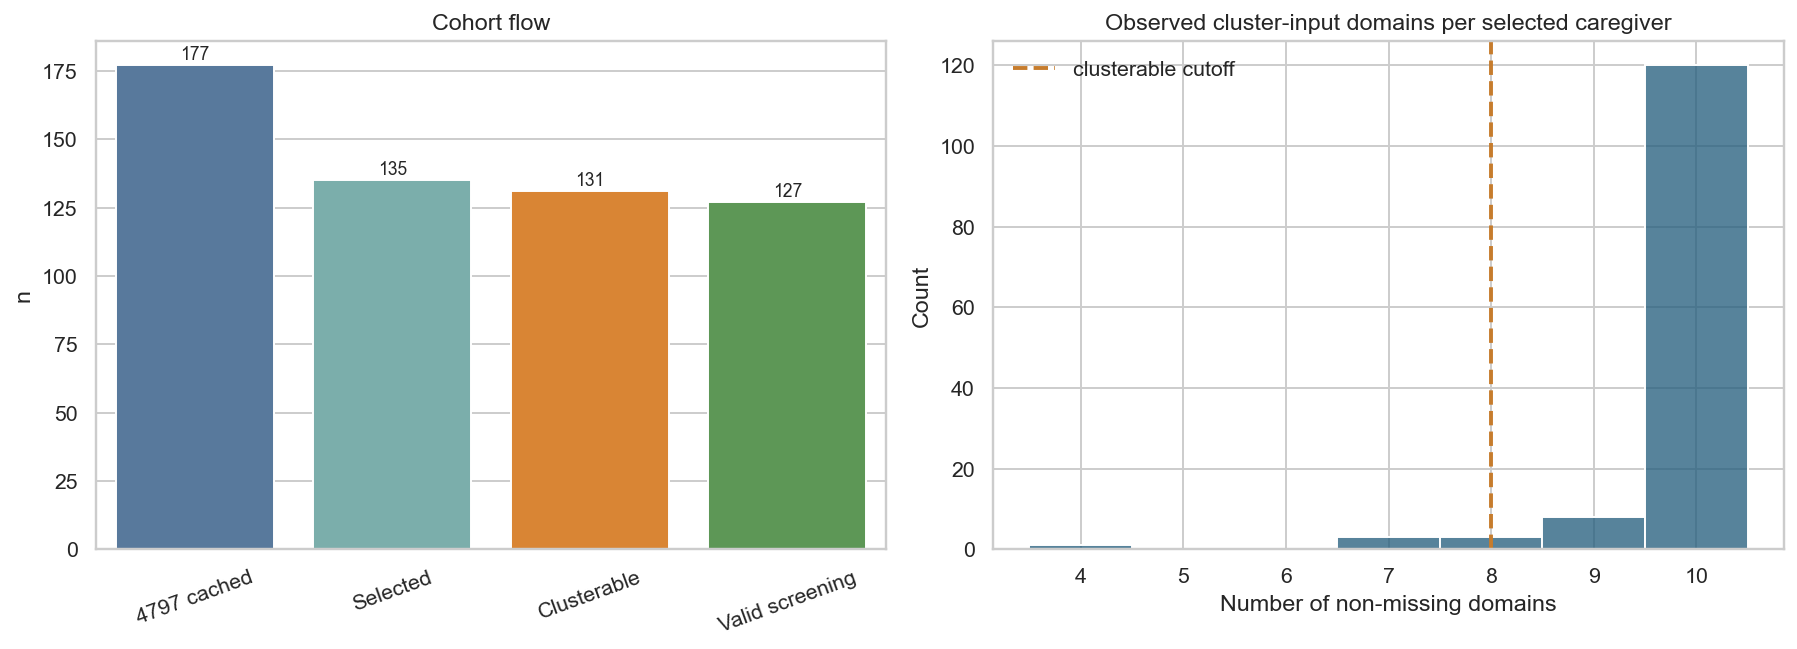

In [4]:
completeness = pd.DataFrame(
    {
        "domains_observed": domain_observed_n,
        "clusterable": domain_observed_n.ge(int(config["analysis"]["minimum_cluster_domains"])),
    }
)

flow_plot = pd.DataFrame(
    [
        {"stage": "4797 cached", "n": len(clean_record)},
        {"stage": "Selected", "n": len(analysis_frame)},
        {"stage": "Clusterable", "n": int(fit.eligible.sum())},
        {"stage": "Valid screening", "n": int(screen_table["valid_n"].sum())},
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(
    data=flow_plot,
    x="stage",
    y="n",
    hue="stage",
    palette=["#4C78A8", "#72B7B2", "#F58518", "#54A24B"],
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cohort flow")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
for index, value in enumerate(flow_plot["n"]):
    axes[0].text(index, value + 2, str(value), ha="center", fontsize=9)

sns.histplot(
    data=completeness,
    x="domains_observed",
    discrete=True,
    color=config["figures"]["blue"],
    ax=axes[1],
)
axes[1].axvline(
    config["analysis"]["minimum_cluster_domains"],
    color=config["figures"]["orange"],
    linestyle="--",
    linewidth=2,
    label="clusterable cutoff",
)
axes[1].set_title("Observed cluster-input domains per selected caregiver")
axes[1].set_xlabel("Number of non-missing domains")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 4. Cluster Fit Quality

A simple cluster summary should show three things together: cluster size balance, case-level silhouette spread, and a low-dimensional view of the fitted clusters. The size chart answers whether the split is usable for comparison, the silhouette plot shows how confidently cases sit in their assigned group, and the PCA panel gives a readable geometric view of the same solution.

/var/folders/z4/kn9vw_0j55s4k90z98drdjpc0000gn/T/ipykernel_26139/2315944726.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


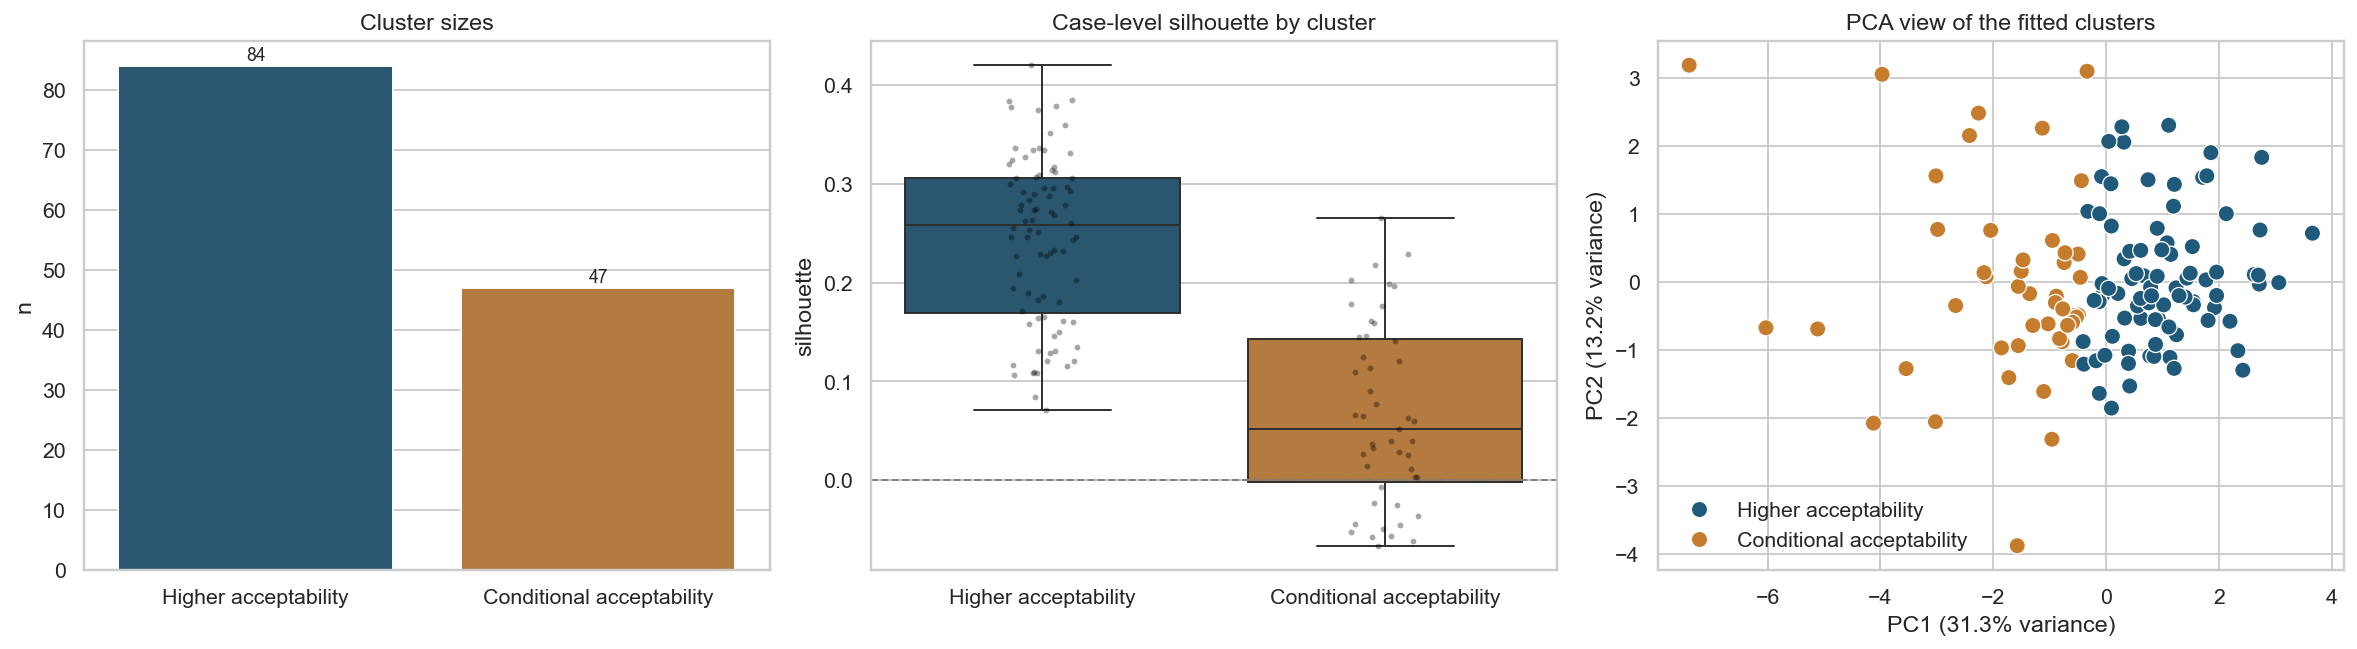

In [5]:
size_table = cluster_sizes.rename_axis("cluster").reset_index(name="n")
silhouette_table = pd.DataFrame(
    {
        "cluster": fit.named_labels.loc[fit.case_silhouette.index].to_numpy(),
        "silhouette": fit.case_silhouette.to_numpy(),
    }
)

pca = PCA(n_components=2, random_state=int(config["analysis"]["seed"]))
pca_scores = pca.fit_transform(fit.X)
pca_table = pd.DataFrame(
    {
        "PC1": pca_scores[:, 0],
        "PC2": pca_scores[:, 1],
        "cluster": fit.named_labels.to_numpy(),
    }
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.barplot(
    data=size_table,
    x="cluster",
    y="n",
    hue="cluster",
    palette=palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cluster sizes")
axes[0].set_xlabel("")
for index, value in enumerate(size_table["n"]):
    axes[0].text(index, value + 1, str(value), ha="center", fontsize=9)

sns.boxplot(
    data=silhouette_table,
    x="cluster",
    y="silhouette",
    order=CLUSTER_ORDER,
    palette=palette,
    ax=axes[1],
)
sns.stripplot(
    data=silhouette_table,
    x="cluster",
    y="silhouette",
    order=CLUSTER_ORDER,
    color="black",
    alpha=0.35,
    size=3,
    ax=axes[1],
)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Case-level silhouette by cluster")
axes[1].set_xlabel("")

sns.scatterplot(
    data=pca_table,
    x="PC1",
    y="PC2",
    hue="cluster",
    hue_order=CLUSTER_ORDER,
    palette=palette,
    s=70,
    ax=axes[2],
)
axes[2].set_title("PCA view of the fitted clusters")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## 5. Cluster-Defining Domains

The most useful profile summary is the domain-level mean difference between clusters. A simple dumbbell chart makes it clear where the separation is largest without hiding the absolute 0 to 100 scale.

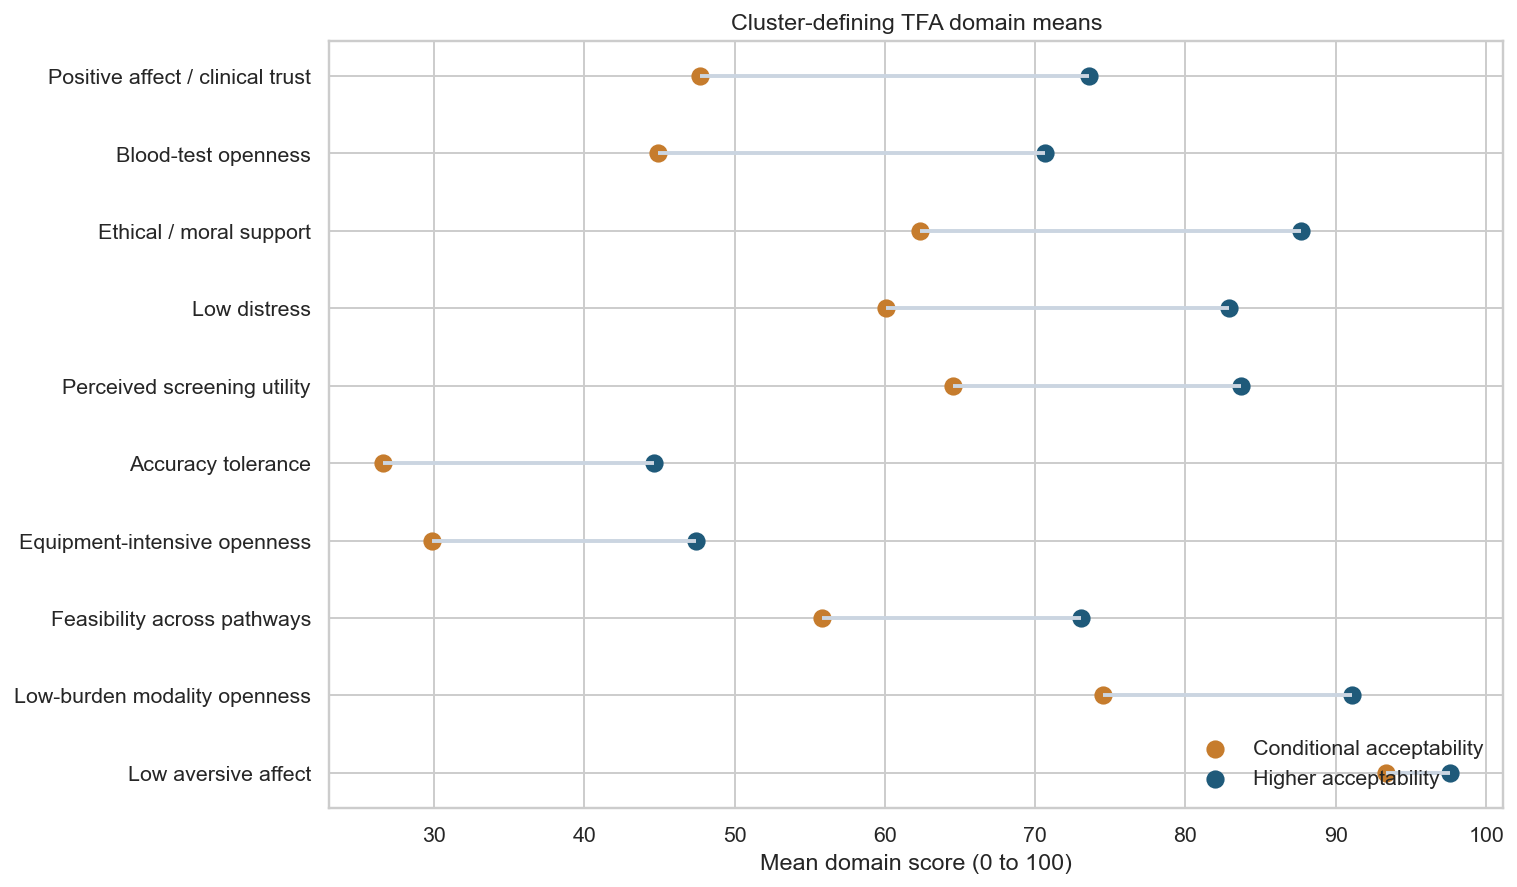

cluster,Higher acceptability,Conditional acceptability,gap
Positive affect / clinical trust,73.6,47.7,25.9
Blood-test openness,70.7,44.9,25.7
Ethical / moral support,87.7,62.3,25.3
Low distress,82.9,60.1,22.8
Perceived screening utility,83.7,64.5,19.2
Accuracy tolerance,44.6,26.6,18.0
Equipment-intensive openness,47.4,29.9,17.5
Feasibility across pathways,73.1,55.8,17.3
Low-burden modality openness,91.1,74.5,16.6
Low aversive affect,97.6,93.4,4.2


In [6]:
plot_table = profile_table.reset_index().rename(columns={"index": "cluster_domain"}).sort_values("gap")

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hlines(
    plot_table["cluster_domain"],
    plot_table["Conditional acceptability"],
    plot_table["Higher acceptability"],
    color="#CBD5E1",
    linewidth=2,
)
ax.scatter(
    plot_table["Conditional acceptability"],
    plot_table["cluster_domain"],
    color=palette["Conditional acceptability"],
    s=70,
    label="Conditional acceptability",
)
ax.scatter(
    plot_table["Higher acceptability"],
    plot_table["cluster_domain"],
    color=palette["Higher acceptability"],
    s=70,
    label="Higher acceptability",
)
ax.set_title("Cluster-defining TFA domain means")
ax.set_xlabel("Mean domain score (0 to 100)")
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

display(profile_table.round(1))

## 6. Held-Out Screening Outcome

This is the most direct decision metric in the project because the screening response is held out of the clustering inputs. If the two-cluster solution is useful, the gap in Definitely yes rates should be visible without needing extra model layers.

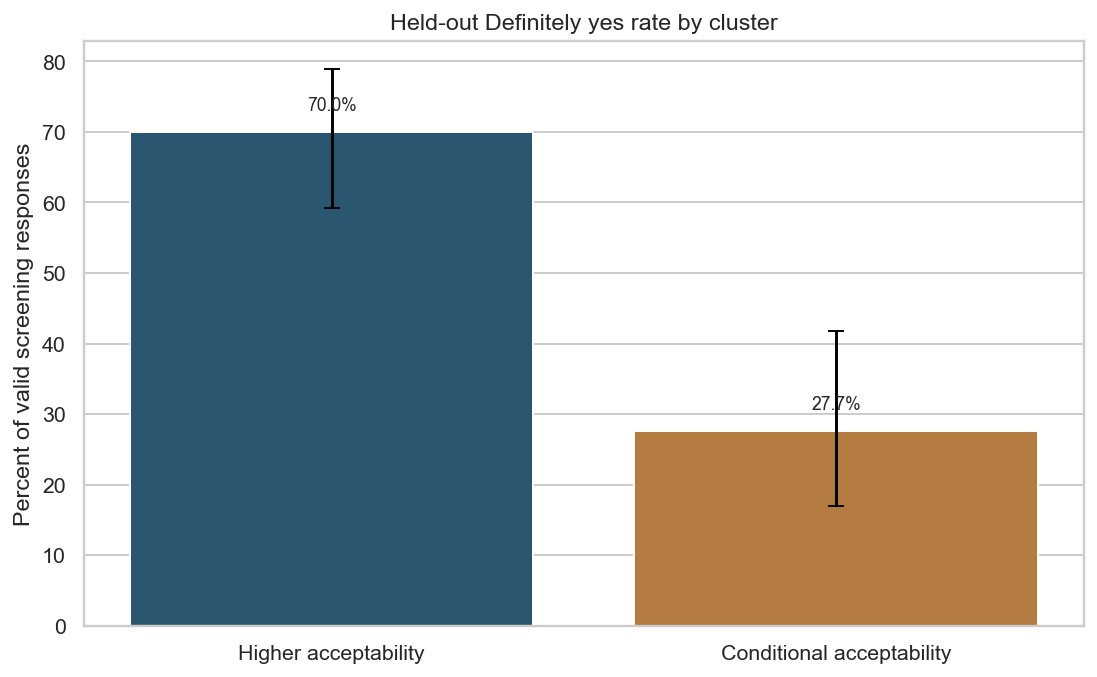

,cluster,valid_n,definitely_yes_n,definitely_yes_pct,wilson_low_pct,wilson_high_pct
0,Higher acceptability,80,56,70.00,59.23,78.94
1,Conditional acceptability,47,13,27.66,16.94,41.76


,metric,value
0,Higher acceptability Definitely yes,70.0% (56/80)
1,Conditional acceptability Definitely yes,27.7% (13/47)
2,Absolute gap,42.3 percentage points
3,Gap 95% interval,17.5 to 62.0 percentage points


In [7]:
screen_plot = screen_table.set_index("cluster").loc[CLUSTER_ORDER].reset_index()
decision_table = pd.DataFrame(
    [
        {"metric": "Higher acceptability Definitely yes", "value": f"{screen_plot.loc[0, 'definitely_yes_pct']:.1f}% ({int(screen_plot.loc[0, 'definitely_yes_n'])}/{int(screen_plot.loc[0, 'valid_n'])})"},
        {"metric": "Conditional acceptability Definitely yes", "value": f"{screen_plot.loc[1, 'definitely_yes_pct']:.1f}% ({int(screen_plot.loc[1, 'definitely_yes_n'])}/{int(screen_plot.loc[1, 'valid_n'])})"},
        {"metric": "Absolute gap", "value": f"{screen_gap:.1f} percentage points"},
        {"metric": "Gap 95% interval", "value": f"{gap_low:.1f} to {gap_high:.1f} percentage points"},
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=screen_plot,
    x="cluster",
    y="definitely_yes_pct",
    hue="cluster",
    order=CLUSTER_ORDER,
    palette=palette,
    legend=False,
    ax=ax,
)
for index, row in screen_plot.iterrows():
    lower_error = row["definitely_yes_pct"] - row["wilson_low_pct"]
    upper_error = row["wilson_high_pct"] - row["definitely_yes_pct"]
    ax.errorbar(
        index,
        row["definitely_yes_pct"],
        yerr=[[lower_error], [upper_error]],
        fmt="none",
        ecolor="black",
        capsize=4,
    )
    ax.text(index, row["definitely_yes_pct"] + 3, f"{row['definitely_yes_pct']:.1f}%", ha="center", fontsize=9)
ax.set_title("Held-out Definitely yes rate by cluster")
ax.set_xlabel("")
ax.set_ylabel("Percent of valid screening responses")

plt.tight_layout()
plt.show()

display(screen_plot.round(2))
display(decision_table)

## 7. How To Use These Metrics

1. Use the clusterable share to check whether the selected cohort is complete enough for clustering.
2. Use cluster size balance and silhouette together: the current split is usable and reasonably balanced, but the silhouette is modest, so the clusters are better treated as practical groupings than hard natural types.
3. Use the domain gap table to explain what separates the clusters in plain language.
4. Use the held-out Definitely yes gap as the main decision metric because it stays outside the clustering inputs and is easy to interpret.
5. Use the validation table to confirm that the notebook still matches the project's committed exports when files are updated.